In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

DATA_DIR = '../data/raw'
TRAIN_CSV = os.path.join(DATA_DIR, 'Train.csv')

Всього зображень: 39209
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


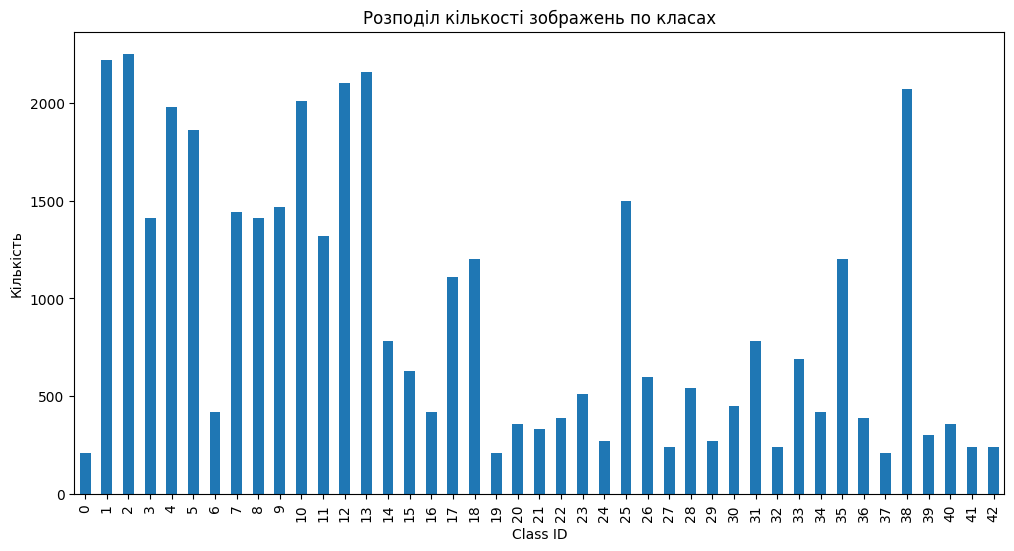

In [2]:
df = pd.read_csv(TRAIN_CSV)
print(f"Всього зображень: {len(df)}")
print(df.head())

plt.figure(figsize=(12, 6))
df['ClassId'].value_counts().sort_index().plot(kind='bar')
plt.title('Розподіл кількості зображень по класах')
plt.xlabel('Class ID')
plt.ylabel('Кількість')
plt.show()

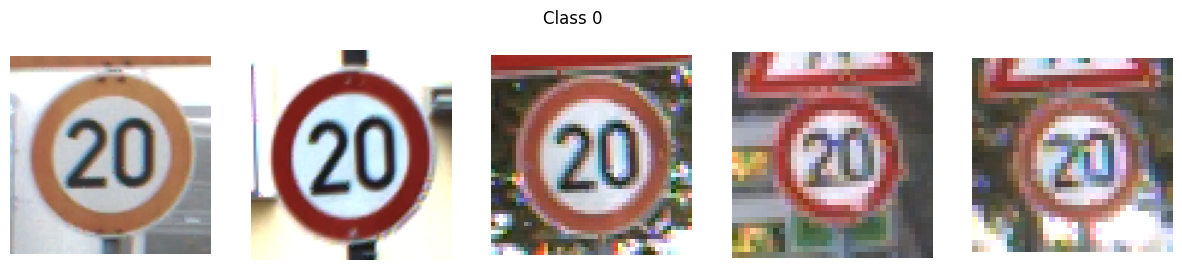

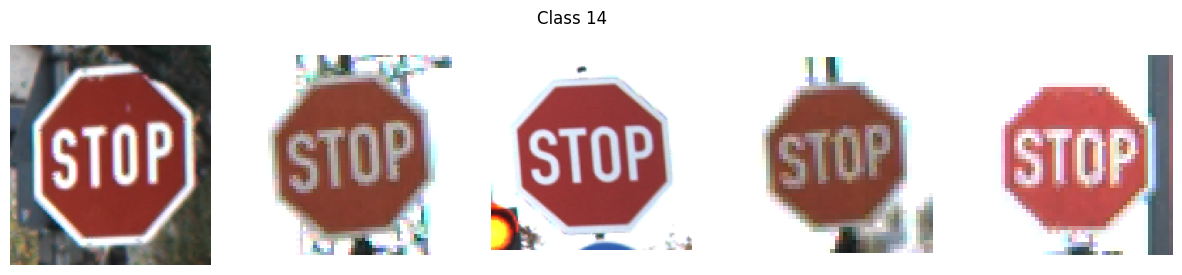

In [3]:
def show_images(class_id, num=5):
    class_df = df[df['ClassId'] == class_id].sample(num)
    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(class_df.iterrows()):
        img_path = os.path.join(DATA_DIR, row['Path']) # Path в CSV зазвичай відносний
        img = Image.open(img_path)
        plt.subplot(1, num, i + 1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f'Class {class_id}')
    plt.show()

show_images(0)
show_images(14)

/var/folders/rf/lsrbmqs563192cqpbwz1qp140000gn/T/ipykernel_57434/2746893765.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


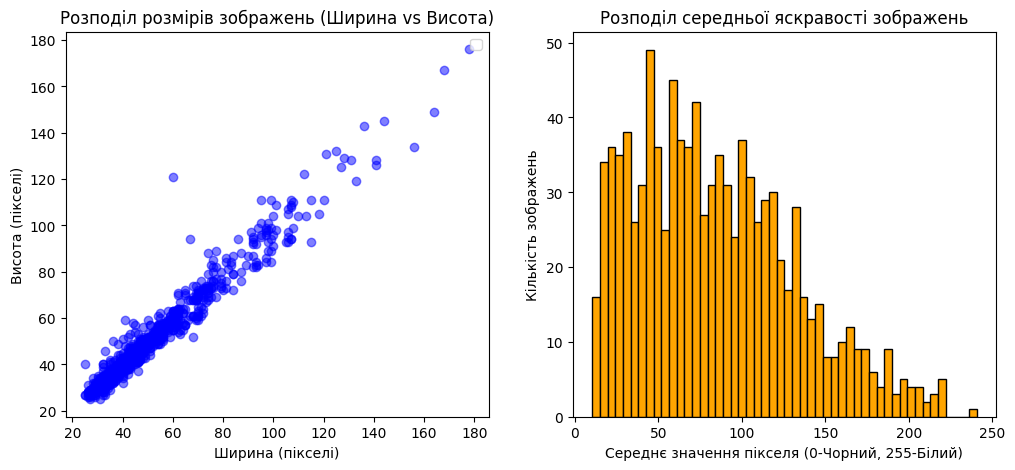

In [7]:
import numpy as np

sample_df = df.sample(1000, random_state=42)

widths, heights, means = [], [], []

for _, row in sample_df.iterrows():
    img_path = os.path.join(DATA_DIR, row['Path'])
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        means.append(np.mean(np.array(img.convert('L'))))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(widths, heights, alpha=0.5, color='blue')
plt.title('Розподіл розмірів зображень (Ширина vs Висота)')
plt.xlabel('Ширина (пікселі)')
plt.ylabel('Висота (пікселі)')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(means, bins=50, color='orange', edgecolor='black')
plt.title('Розподіл середньої яскравості зображень')
plt.xlabel('Середнє значення пікселя (0-Чорний, 255-Білий)')
plt.ylabel('Кількість зображень')

plt.show()
